<a href="https://colab.research.google.com/github/jovicma/euro2024-ace-lab-analysis/blob/main/notebooks/01_analise_ipf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instala o pacote oficial da StatsBomb
!pip install statsbombpy -q

import pandas as pd
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore') # Oculta os avisos padrão da biblioteca para manter o notebook limpo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.8 MB/s eta 0:00:00


In [2]:
# 1. Obter todas as partidas da Eurocopa 2024
# competition_id=55 (UEFA Euro), season_id=282 (2024)
df_matches = sb.matches(competition_id=55, season_id=282)
match_ids = df_matches['match_id'].tolist()

print(f"Total de partidas encontradas: {len(match_ids)}")

# 2. Extrair os chutes de todas as partidas
all_shots = []

print("Extraindo eventos (isso pode levar alguns segundos)...")
for match_id in match_ids:
    # Puxa o dataframe de eventos da partida específica
    df_events = sb.events(match_id=match_id)

    # Filtra apenas as linhas onde o tipo do evento é 'Shot'
    if 'Shot' in df_events['type'].values:
        shots = df_events[df_events['type'] == 'Shot'].copy()
        all_shots.append(shots)

# Concatena a lista de DataFrames em um único DataFrame contendo todos os chutes da Euro
df_all_shots = pd.concat(all_shots, ignore_index=True)
print(f"Total de finalizações (Shots) na competição: {len(df_all_shots)}")

Total de partidas encontradas: 51
Extraindo eventos (isso pode levar alguns segundos)...
Total de finalizações (Shots) na competição: 1340


In [3]:
# 3. Filtrar Pênaltis (Queremos apenas Non-Penalty Shots)
# A StatsBomb classifica o tipo do chute na coluna 'shot_type'
df_np_shots = df_all_shots[df_all_shots['shot_type'] != 'Penalty'].copy()

# 4. Criar variáveis binárias para Gols
# Na StatsBomb, o resultado do chute está em 'shot_outcome'
df_np_shots['is_goal'] = (df_np_shots['shot_outcome'] == 'Goal').astype(int)

# O xG do chute fica armazenado na coluna 'shot_statsbomb_xg'
# Garantir que não existam valores nulos (preenchendo com 0 por segurança)
df_np_shots['shot_statsbomb_xg'] = df_np_shots['shot_statsbomb_xg'].fillna(0)

# 5. Agrupar os dados por seleção
team_ipf = df_np_shots.groupby('team').agg(
    np_shots=('id', 'count'), # Conta o número de IDs de eventos (chutes totais)
    npg=('is_goal', 'sum'),   # Soma total de gols sem pênalti
    npxG=('shot_statsbomb_xg', 'sum') # Soma total de xG sem pênalti
).reset_index()

# 6. Calcular a métrica IPF
team_ipf['IPF'] = (team_ipf['npg'] - team_ipf['npxG']) / team_ipf['np_shots']

# 7. Visualizar o resultado ranqueado do melhor para o pior
team_ipf = team_ipf.sort_values(by='IPF', ascending=False).reset_index(drop=True)

# Formatação final para leitura
team_ipf['IPF'] = team_ipf['IPF'].round(4)
team_ipf['npxG'] = team_ipf['npxG'].round(2)

display(team_ipf)

,team,np_shots,npg,npxG,IPF
0,Switzerland,58,8,5.35,0.0457
1,Spain,123,14,10.57,0.0278
2,Albania,32,3,2.18,0.0255
3,Turkey,72,8,6.46,0.0213
4,Netherlands,83,9,7.32,0.0203
5,Germany,93,9,7.16,0.0198
6,England,75,7,5.81,0.0159
7,Slovakia,50,4,3.83,0.0035
8,Romania,37,3,2.97,0.0007
9,Scotland,17,1,1.02,-0.0009


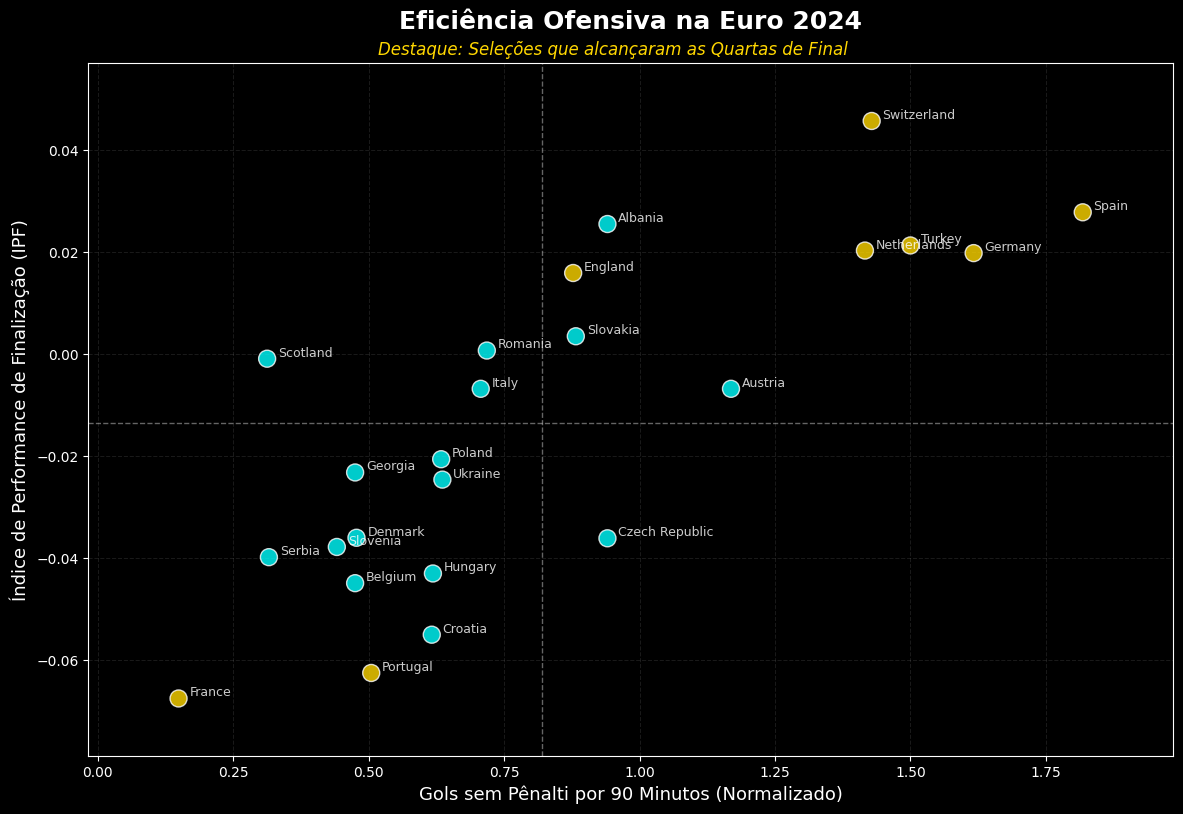

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Seleções que chegaram às quartas de final da Euro 2024 (Nomes em inglês como na StatsBomb)
quartas_euro = ['Spain', 'Germany', 'Portugal', 'France', 'Netherlands', 'Turkey', 'England', 'Switzerland']

# Criando a coluna de cores com base na lista
team_ipf['color'] = np.where(team_ipf['team'].isin(quartas_euro), 'gold', 'cyan')

# --- Geração do Gráfico ---
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 9))

# Plot principal
ax.scatter(
    team_ipf["npg_per_90"],
    team_ipf["IPF"],
    c=team_ipf["color"], # Aplica as cores definidas (dourado ou ciano)
    edgecolors="white",
    alpha=0.8,
    s=150,
    zorder=3
)

# Adicionar nomes das seleções em cada ponto
for i in range(team_ipf.shape[0]):
    ax.text(
        team_ipf.npg_per_90[i] + 0.02,
        team_ipf.IPF[i] + 0.0005,
        team_ipf.team[i],
        fontsize=9,
        color='white',
        alpha=0.8
    )

# Linhas de média para criar quadrantes de análise
ax.axvline(team_ipf["npg_per_90"].mean(), linestyle="--", color="white", alpha=0.4, linewidth=1)
ax.axhline(team_ipf["IPF"].mean(), linestyle="--", color="white", alpha=0.4, linewidth=1)

# Configurações de Título e Eixos
ax.set_title("Eficiência Ofensiva na Euro 2024", fontsize=18, color="white", fontweight="bold", pad=25)

# --- AJUSTE DO SUBTÍTULO ---
# O segundo valor (0.89) controla a altura no eixo Y.
# Se precisar descer mais, diminua (ex: 0.86). Se precisar subir, aumente (ex: 0.92).
fig.text(0.5, 0.89, 'Destaque: Seleções que alcançaram as Quartas de Final',
         ha='center', fontsize=12, color='gold', style='italic')

ax.set_xlabel("Gols sem Pênalti por 90 Minutos (Normalizado)", fontsize=13, color="white")
ax.set_ylabel("Índice de Performance de Finalização (IPF)", fontsize=13, color="white")

ax.grid(True, linestyle="--", alpha=0.1)

# Ajuste fino da escala
plt.margins(0.1)

plt.savefig("analise_eficiencia_euro2024.png", dpi=300, bbox_inches="tight")
plt.show()